In [11]:
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt
import cv2
import joblib

In [2]:
data = np.load("final_embedding.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

In [3]:
print(X_train.shape)
print(X_test.shape)

(336, 512)
(90, 512)


In [4]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [5]:
model=SVC(kernel='rbf',probability=True)
model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
y_pred=model.predict(X_test)

In [7]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

Accuracy Score: 0.91


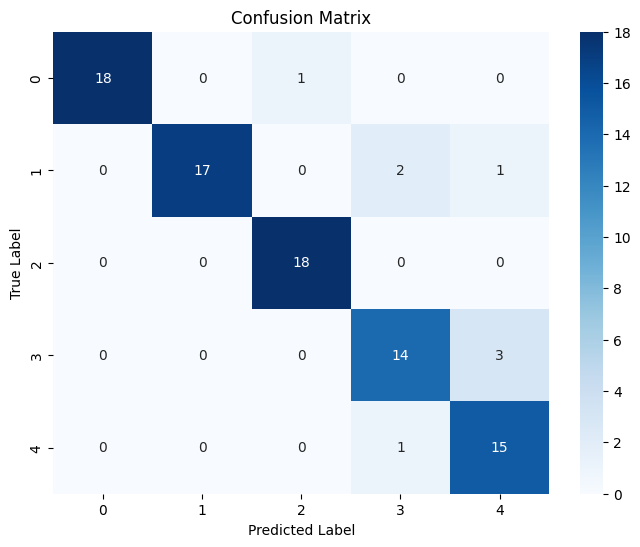

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,      # show numbers in cells
    fmt='d',         # integer format
    cmap='Blues'     # color map
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [12]:
image_embedding = np.load("embedding.npy")

In [13]:
image_embedding=sc.transform(image_embedding)

In [14]:
model.predict(image_embedding)

array([1])

In [ ]:
joblib.dump(model, "svm_model.pkl")
joblib.dump(sc, "standard_scaler.pkl")